In [15]:
import copy
import os
import time
import warnings

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import auc, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from xgboost import XGBClassifier


### Data Foundation & Metadata Preparation 

In [2]:
csv_path = 'dataset/HAM10000_metadata.csv' 
folder_1 = 'dataset/HAM10000_images_part_1/' 
folder_2 = 'dataset/HAM10000_images_part_2/'


df = pd.read_csv(csv_path)


encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['dx'])


class_mapping = dict(zip(encoder.classes_, range(len(encoder.classes_))))
print(f"Class Mapping: {class_mapping}")

image_paths = []
valid_indices = []

for idx, row in df.iterrows():
    file_name = f"{row['image_id']}.jpg"
    path_1 = os.path.join(folder_1, file_name)
    path_2 = os.path.join(folder_2, file_name)
    
    if os.path.exists(path_1):
        image_paths.append(path_1)
        valid_indices.append(idx)
    elif os.path.exists(path_2):
        image_paths.append(path_2)
        valid_indices.append(idx)

df_valid = df.iloc[valid_indices].copy()
df_valid['image_path'] = image_paths

print("Formatting clinical metadata...")

df_valid['age'] = df_valid['age'].fillna(df_valid['age'].median())

metadata_encoded = pd.get_dummies(df_valid[['sex', 'localization']])

scaler_age = StandardScaler()
age_scaled = scaler_age.fit_transform(df_valid[['age']])

metadata_encoded.insert(0, 'age_scaled', age_scaled)

metadata_features = metadata_encoded.to_numpy(dtype=np.float64)
labels = df_valid['label'].to_numpy()

print("-" * 60)
print(f"Successfully secured {len(df_valid)} real image paths.")
print(f"Metadata perfectly formatted. Shape: {metadata_features.shape}")
print(f"Labels Shape: {labels.shape}")
print("-" * 60)

Class Mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Formatting clinical metadata...
------------------------------------------------------------
Successfully secured 10015 real image paths.
Metadata perfectly formatted. Shape: (10015, 19)
Labels Shape: (10015,)
------------------------------------------------------------


### Preprocessing & Dynamic Augmentation.

In [3]:
def remove_hair(image):
    grayScale = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    clean_image = cv2.inpaint(image, mask, 1, cv2.INPAINT_TELEA)
    return clean_image

print("Engaging CPU for Clinical Preprocessing (Hair Removal)...")
start_time = time.time()

processed_images = []
image_paths_list = df_valid['image_path'].tolist()

for i, path in enumerate(image_paths_list):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = remove_hair(img)             
    img = cv2.resize(img, (224, 224))  # Resize for ResNet50
    processed_images.append(img)
    
    if (i + 1) % 2000 == 0:
        print(f"Processed {i + 1}/{len(image_paths_list)} images...")

print(f"Preprocessing Complete! Time: {(time.time() - start_time) / 60:.2f} minutes.")
processed_images = np.array(processed_images)

print("\nSplitting data into Train and Test sets...")
indices = np.arange(len(labels))

train_idx, test_idx = train_test_split(
    indices, test_size=0.20, stratify=labels, random_state=42
)

X_train_img, X_test_img = processed_images[train_idx], processed_images[test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]
meta_train, meta_test = metadata_features[train_idx], metadata_features[test_idx]

print(f"Training Images: {len(X_train_img)} | Testing Images: {len(X_test_img)}")

class SkinLesionDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

train_transforms = transforms.Compose([
    transforms.ToPILImage(), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = SkinLesionDataset(X_train_img, y_train, transform=train_transforms)
test_dataset = SkinLesionDataset(X_test_img, y_test, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\nPyTorch DataLoaders successfully mapped with Dynamic Augmentation!")

Engaging CPU for Clinical Preprocessing (Hair Removal)...
Processed 2000/10015 images...
Processed 4000/10015 images...
Processed 6000/10015 images...
Processed 8000/10015 images...
Processed 10000/10015 images...
Preprocessing Complete! Time: 2.00 minutes.

Splitting data into Train and Test sets...
Training Images: 8012 | Testing Images: 2003

PyTorch DataLoaders successfully mapped with Dynamic Augmentation!


### Unweighted Deep Fine-Tuning 

In [4]:

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Active Device: {device}")

print("\nLoading pre-trained ResNet50 & Resetting Architecture...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
])

num_epochs = 10
print(f"\nStarting unweighted deep fine-tuning for {num_epochs} epochs...\n")

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    start_time = time.time()
    
   
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    
    model.eval()
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_acc = (correct_val / total_val) * 100
    epoch_time = (time.time() - start_time) / 60
    
   
    scheduler.step(epoch_val_acc)
    current_lr = optimizer.param_groups[1]['lr']
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {epoch_time:.2f} min | LR: {current_lr:.6f}")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")
    
    
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        print(">>> New Best Validation Accuracy! Saving uncollapsed weights...")
        
    print("-" * 60)

model.load_state_dict(best_model_wts)
print(f"\nTraining Complete! Best Validation Accuracy: {best_val_acc:.2f}%")
print("ResNet50 is now deeply optimized WITHOUT feature collapse. Ready for extraction.")

Active Device: mps

Loading pre-trained ResNet50 & Resetting Architecture...

Starting unweighted deep fine-tuning for 10 epochs...

Epoch [1/10] | Time: 1.15 min | LR: 0.000100
Train Loss: 0.7420 | Train Acc: 73.49% | Val Acc: 77.78%
>>> New Best Validation Accuracy! Saving uncollapsed weights...
------------------------------------------------------------
Epoch [2/10] | Time: 1.15 min | LR: 0.000100
Train Loss: 0.5740 | Train Acc: 78.66% | Val Acc: 80.98%
>>> New Best Validation Accuracy! Saving uncollapsed weights...
------------------------------------------------------------
Epoch [3/10] | Time: 1.15 min | LR: 0.000100
Train Loss: 0.5223 | Train Acc: 80.42% | Val Acc: 80.98%
------------------------------------------------------------
Epoch [4/10] | Time: 1.14 min | LR: 0.000100
Train Loss: 0.4710 | Train Acc: 82.23% | Val Acc: 81.98%
>>> New Best Validation Accuracy! Saving uncollapsed weights...
------------------------------------------------------------
Epoch [5/10] | Time: 1.

### Feature Extraction & Fusion

In [5]:

print("Removing the classification head to expose the deeply optimized 2048 feature layer...")
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval() 


extract_train_dataset = SkinLesionDataset(X_train_img, y_train, transform=test_transforms)
extract_train_loader = DataLoader(extract_train_dataset, batch_size=32, shuffle=False)
extract_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def get_features(loader):
    features = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = feature_extractor(images)
            outputs = outputs.view(outputs.size(0), -1) 
            features.append(outputs.cpu().numpy())
    return np.vstack(features)


print("Extracting custom dermatological features from Training Set...")
X_train_features = get_features(extract_train_loader)

print("Extracting custom dermatological features from Testing Set...")
X_test_features = get_features(extract_test_loader)

print(f"\nExtracted Train Features: {X_train_features.shape}")
print(f"Extracted Test Features: {X_test_features.shape}")

print("\nFusing newly learned visual features with clinical metadata...")
X_train_fused = np.hstack((X_train_features, meta_train))
X_test_fused = np.hstack((X_test_features, meta_test))

print(f"Final Multimodal Train Shape: {X_train_fused.shape}")
print(f"Final Multimodal Test Shape: {X_test_fused.shape}")


print("\nSaving final arrays to disk...")
np.save('X_train_fused_optimized.npy', X_train_fused)
np.save('X_test_fused_optimized.npy', X_test_fused)
np.save('y_train_optimized.npy', y_train)
np.save('y_test_optimized.npy', y_test)
print("Backup complete!")

Removing the classification head to expose the deeply optimized 2048 feature layer...
Extracting custom dermatological features from Training Set...
Extracting custom dermatological features from Testing Set...

Extracted Train Features: (8012, 2048)
Extracted Test Features: (2003, 2048)

Fusing newly learned visual features with clinical metadata...
Final Multimodal Train Shape: (8012, 2067)
Final Multimodal Test Shape: (2003, 2067)

Saving final arrays to disk...
Backup complete!


### SMOTE & High-Dimensional Evaluation

In [6]:
print("Sanitizing features for mathematical stability...")
X_train_clean = np.nan_to_num(X_train_fused.astype(np.float64), nan=0.0, posinf=1e6, neginf=-1e6)
X_test_clean = np.nan_to_num(X_test_fused.astype(np.float64), nan=0.0, posinf=1e6, neginf=-1e6)


selector = np.var(X_train_clean, axis=0) > 1e-10
X_train_clean = X_train_clean[:, selector]
X_test_clean = X_test_clean[:, selector]


print("\nApplying SMOTE to the 2067-dimensional feature space...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_clean, y_train)
print(f"Training features expanded from {X_train_clean.shape[0]} to {X_train_resampled.shape[0]} samples.")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled) # Fit strictly on the SMOTE data
X_test_scaled = scaler.transform(X_test_clean)


X_train_scaled = np.clip(X_train_scaled, -10, 10)
X_test_scaled = np.clip(X_test_scaled, -10, 10)

class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


print("\nTraining the SMOTE-Enhanced SVM...")
svm_clf = SVC(kernel='rbf', C=15.0, gamma='scale', probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train_resampled)

print("\n" + "="*40)
print("        SVM CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, svm_clf.predict(X_test_scaled), target_names=class_names))


Sanitizing features for mathematical stability...

Applying SMOTE to the 2067-dimensional feature space...
Training features expanded from 8012 to 37548 samples.

Training the SMOTE-Enhanced SVM...

        SVM CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec       0.67      0.72      0.70        65
         bcc       0.81      0.77      0.79       103
         bkl       0.75      0.70      0.72       220
          df       0.95      0.83      0.88        23
         mel       0.63      0.69      0.66       223
          nv       0.94      0.94      0.94      1341
        vasc       0.96      0.89      0.93        28

    accuracy                           0.87      2003
   macro avg       0.82      0.79      0.80      2003
weighted avg       0.87      0.87      0.87      2003



### Evaluation & Metrics Report 

--- MODULE 7: ACADEMIC VISUALIZATIONS & METRICS ---
Calculating predictions and probabilities...
Generating Confusion Matrix...
Saved: Confusion_Matrix_SVM.png


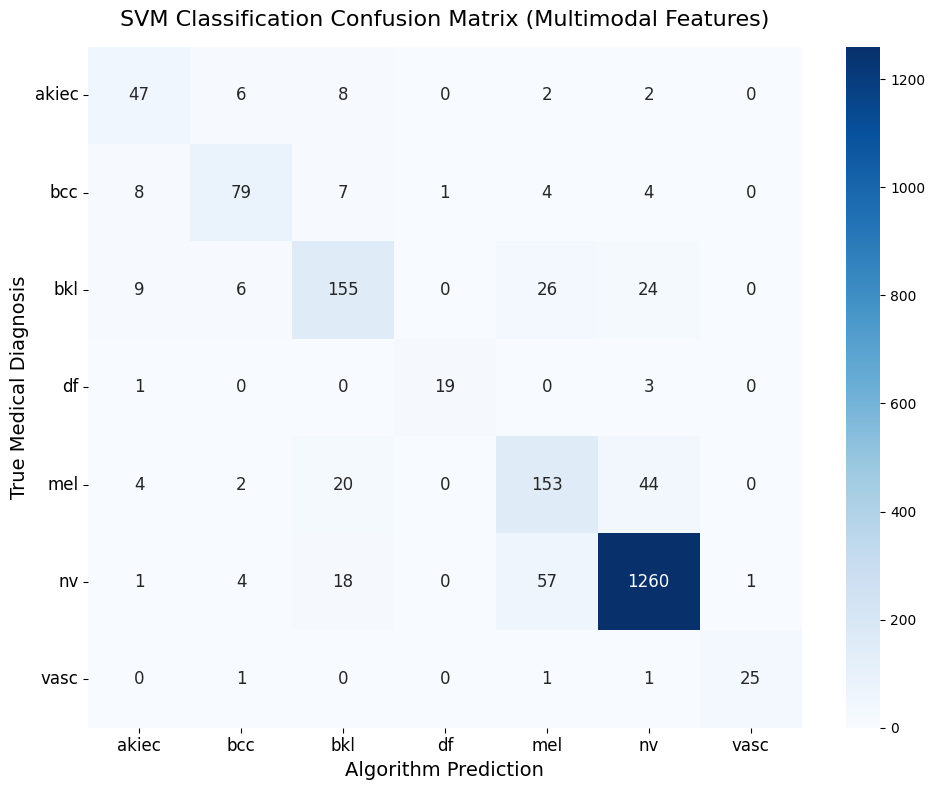


Generating ROC-AUC Curves...
Saved: ROC_AUC_Curves_SVM.png


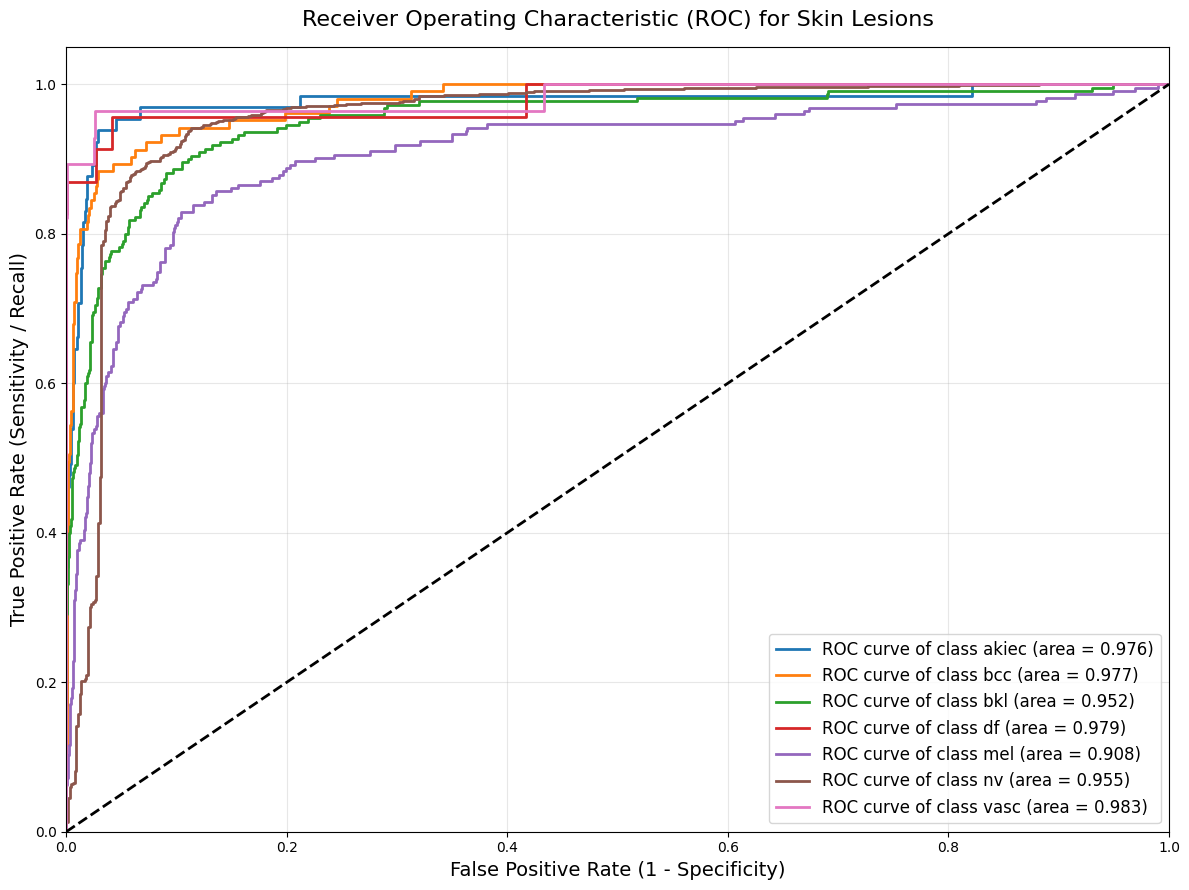


Generating Final Text Report...

 FINAL SVM CLASSIFICATION REPORT FOR DOCUMENTATION
              precision    recall  f1-score   support

       akiec       0.67      0.72      0.70        65
         bcc       0.81      0.77      0.79       103
         bkl       0.75      0.70      0.72       220
          df       0.95      0.83      0.88        23
         mel       0.63      0.69      0.66       223
          nv       0.94      0.94      0.94      1341
        vasc       0.96      0.89      0.93        28

    accuracy                           0.87      2003
   macro avg       0.82      0.79      0.80      2003
weighted avg       0.87      0.87      0.87      2003


Saved: Classification_Metrics_Report.txt


In [14]:
print("--- MODULE 7: ACADEMIC VISUALIZATIONS & METRICS ---")


class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
n_classes = len(class_names)


print("Calculating predictions and probabilities...")
y_pred_svm = svm_clf.predict(X_test_scaled)
y_score_svm = svm_clf.predict_proba(X_test_scaled)


print("Generating Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12})
plt.title('SVM Classification Confusion Matrix (Multimodal Features)', fontsize=16, pad=15)
plt.ylabel('True Medical Diagnosis', fontsize=14)
plt.xlabel('Algorithm Prediction', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()

# Save the plot to your hard drive
plt.savefig('Confusion_Matrix_SVM.png', dpi=300)
print("Saved: Confusion_Matrix_SVM.png")
plt.show()



print("\nGenerating ROC-AUC Curves...")
# Binarize the test labels for One-vs-Rest ROC calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4, 5, 6])

# Calculate False Positive Rate, True Positive Rate, and Area Under Curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves together
plt.figure(figsize=(12, 9))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.3f})')

# Add the random guessing diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) for Skin Lesions', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig('ROC_AUC_Curves_SVM.png', dpi=300)
print("Saved: ROC_AUC_Curves_SVM.png")
plt.show()


print("\nGenerating Final Text Report...")
report = classification_report(y_test, y_pred_svm, target_names=class_names)
print("\n" + "="*50)
print(" FINAL SVM CLASSIFICATION REPORT FOR DOCUMENTATION")
print("="*50)
print(report)

# Save the text report
with open('Classification_Metrics_Report.txt', 'w') as f:
    f.write("Skin Lesion Classification - Final SVM Metrics\n")
    f.write("==============================================\n\n")
    f.write(report)
print("\nSaved: Classification_Metrics_Report.txt")

### Save the pipeline

In [16]:

print("--- EXPORTING MODELS FOR PRODUCTION ---")

save_dir = '../saved_models/'

os.makedirs(save_dir, exist_ok=True)

torch.save(feature_extractor.state_dict(), os.path.join(save_dir, 'resnet50_extractor.pth'))

joblib.dump(svm_clf, os.path.join(save_dir, 'svm_model.joblib'))
joblib.dump(scaler, os.path.join(save_dir, 'main_feature_scaler.joblib'))
joblib.dump(scaler_age, os.path.join(save_dir, 'age_scaler.joblib'))


joblib.dump(list(metadata_encoded.columns), os.path.join(save_dir, 'metadata_columns.joblib'))
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
joblib.dump(class_names, os.path.join(save_dir, 'class_names.joblib'))

print(f"Export complete! All physical files safely stored in: {os.path.abspath(save_dir)}")

--- EXPORTING MODELS FOR PRODUCTION ---
Export complete! All physical files safely stored in: /Users/halilbayat/Desktop/PhD/Pattern Recognition&Analysis/project/skin-lesion-diagnosis/saved_models
